## Sales Analysis

### Monthly sales trend

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
main_df = pd.read_csv('../data/featured_dataset.csv')

In [10]:
# Beacuse we have duplicate orders then plot will be mislead
orders_df = main_df.drop_duplicates(subset="order_id")

main_df['order_purchase_timestamp'] = pd.to_datetime(
    main_df['order_purchase_timestamp'],
    errors='coerce'
)

# Then group by purchase month and sum total_payment_value
monthly_sales = (
    orders_df
    .groupby(orders_df["order_purchase_timestamp"].dt.to_period("M"))["total_payment_value"]
    .sum()
)
monthly_sales

order_purchase_timestamp
2016-09        252.24
2016-10      58863.52
2016-12         19.62
2017-01     138488.04
2017-02     291908.01
2017-03     449863.60
2017-04     417788.03
2017-05     592918.82
2017-06     511276.38
2017-07     592382.92
2017-08     674396.32
2017-09     727762.45
2017-10     779677.88
2017-11    1194599.11
2017-12     878134.67
2018-01    1115004.18
2018-02     992325.74
2018-03    1159652.12
2018-04    1160785.48
2018-05    1153982.15
2018-06    1023880.50
2018-07    1066540.75
2018-08    1022425.32
2018-09       4439.54
2018-10        589.67
Freq: M, Name: total_payment_value, dtype: float64

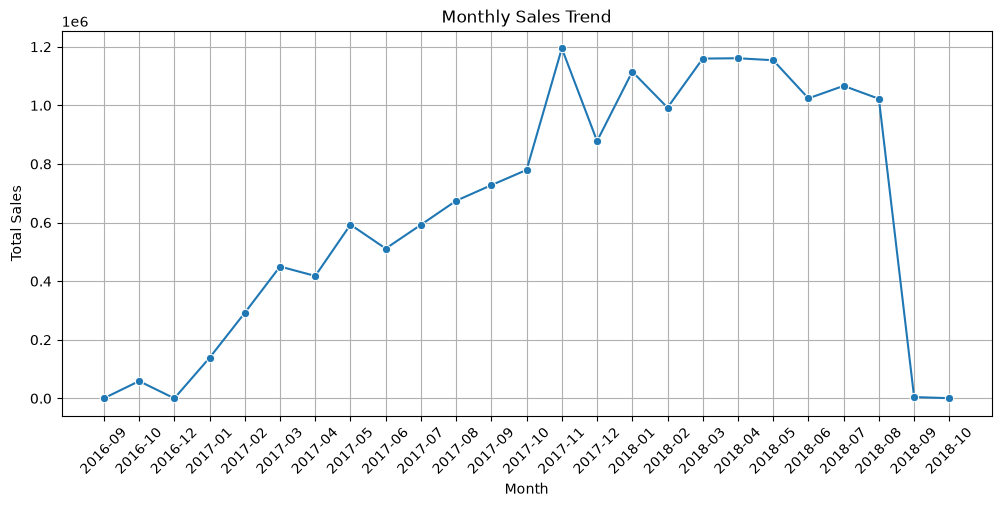

In [11]:
# Changing index to string for x-axis
monthly_sales.index = monthly_sales.index.astype(str)

# Creating figure with specific size
plt.figure(figsize=(12, 5))

sns.lineplot(x=monthly_sales.index, y=monthly_sales.values, marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.grid(True)
plt.show()

In [12]:
# Checking the last 2 months drop
orders_df.groupby(
    orders_df["order_purchase_timestamp"].dt.to_period("M")
)["order_id"].nunique()

order_purchase_timestamp
2016-09       4
2016-10     321
2016-12       1
2017-01     800
2017-02    1780
2017-03    2682
2017-04    2404
2017-05    3700
2017-06    3245
2017-07    4026
2017-08    4331
2017-09    4285
2017-10    4631
2017-11    7542
2017-12    5671
2018-01    7269
2018-02    6727
2018-03    7211
2018-04    6939
2018-05    6873
2018-06    6167
2018-07    6292
2018-08    6512
2018-09      16
2018-10       4
Freq: M, Name: order_id, dtype: int64

### Revenue by Category

In [13]:
revenue_by_category = pd.DataFrame(main_df.groupby(main_df['product_category_name'])['price'].sum())

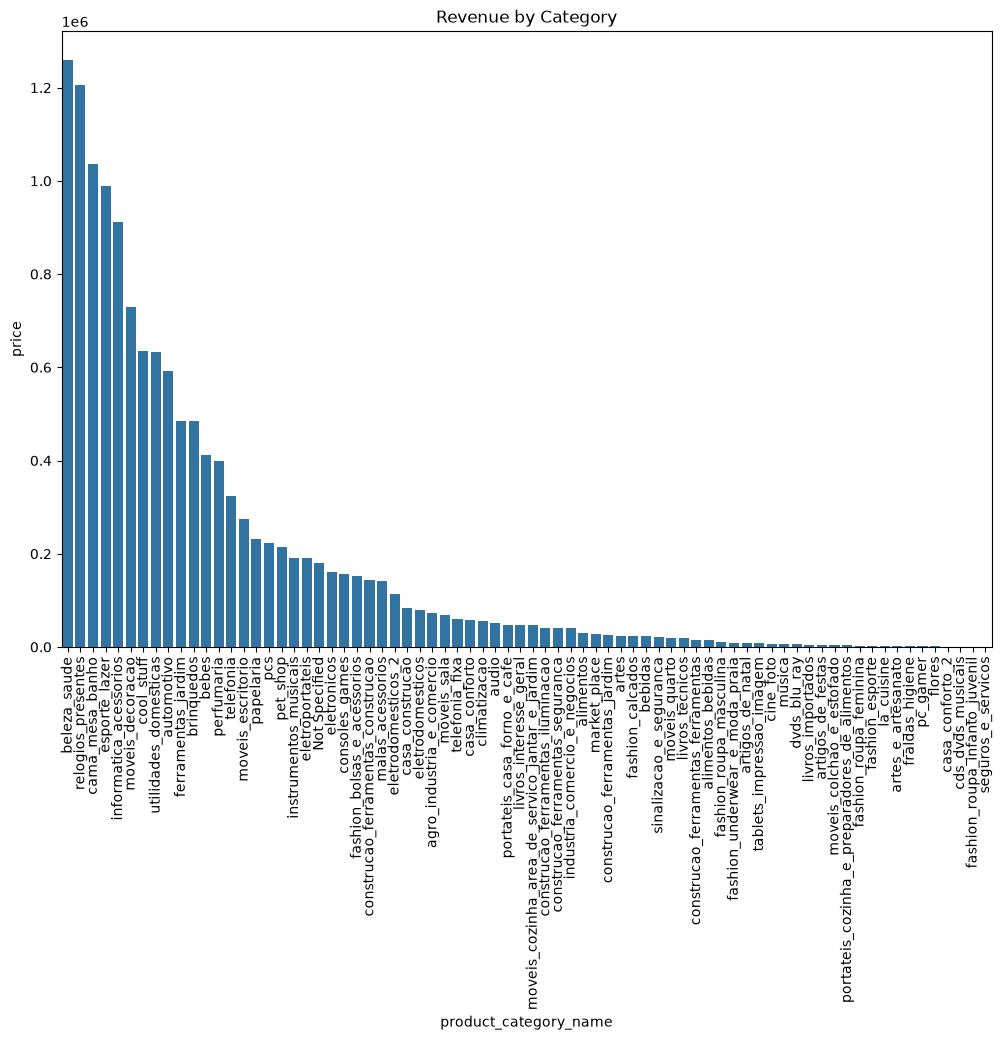

In [14]:
revenue_by_category = revenue_by_category.reset_index()
revenue_by_category = revenue_by_category[['product_category_name','price']].sort_values(by='price', ascending=False)
plt.figure(figsize=(12, 8))
sns.barplot(
    data=revenue_by_category,
    x='product_category_name',
    y='price'
)
plt.title("Revenue by Category")
plt.xticks(rotation=90)
plt.show()

### Revenue by State

In [15]:
revenue_by_state = pd.DataFrame(main_df.groupby(main_df['seller_state'])['price'].sum())

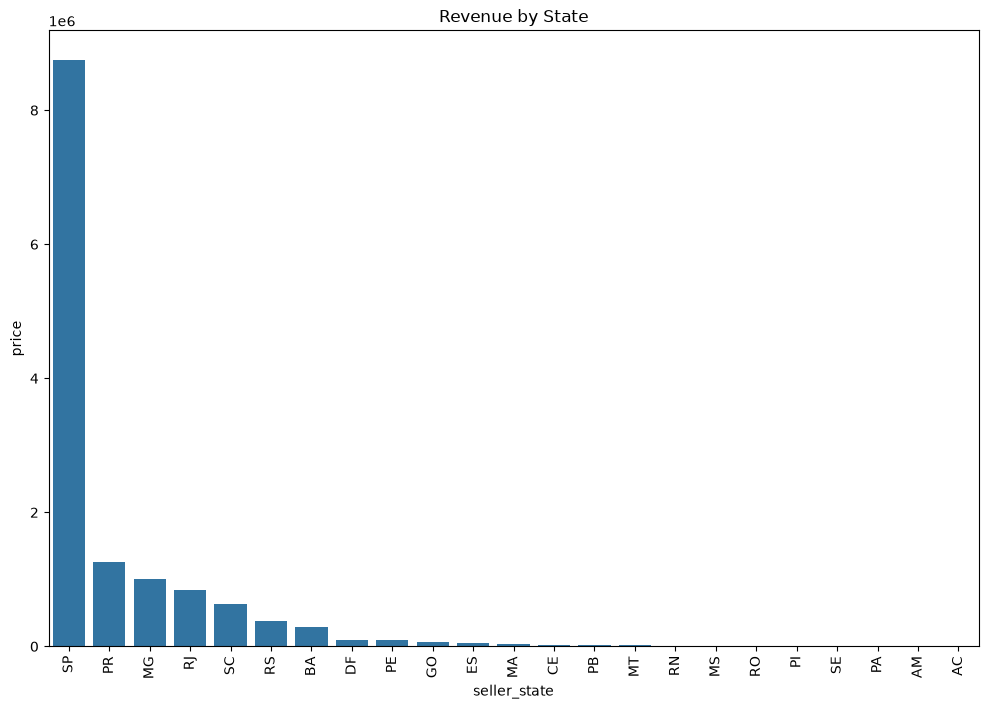

In [16]:
revenue_by_state = revenue_by_state.reset_index()
revenue_by_state = revenue_by_state[['seller_state','price']].sort_values(by='price', ascending=False)
plt.figure(figsize=(12, 8))
sns.barplot(
    data=revenue_by_state,
    x='seller_state',
    y='price'
)
plt.title("Revenue by State")
plt.xticks(rotation=90)
plt.show()

## Customer Analysis

### Top Purchasing Cities by customers

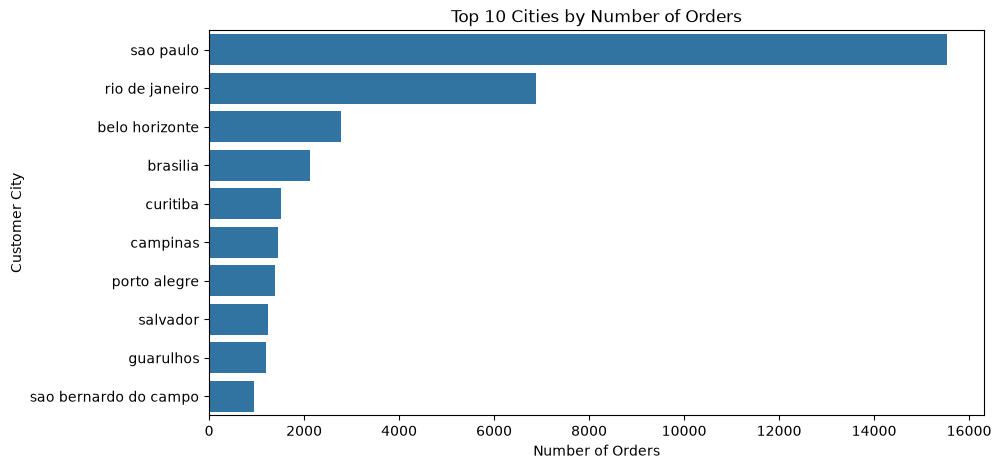

In [20]:
# Getting Top 10 Cities
city_orders = (
    main_df.groupby('customer_city')['order_id']
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
sns.barplot(
    x=city_orders.values,
    y=city_orders.index
)

plt.title("Top 10 Cities by Number of Orders")
plt.xlabel("Number of Orders")
plt.ylabel("Customer City")
plt.show()

### Top Customers Spending 

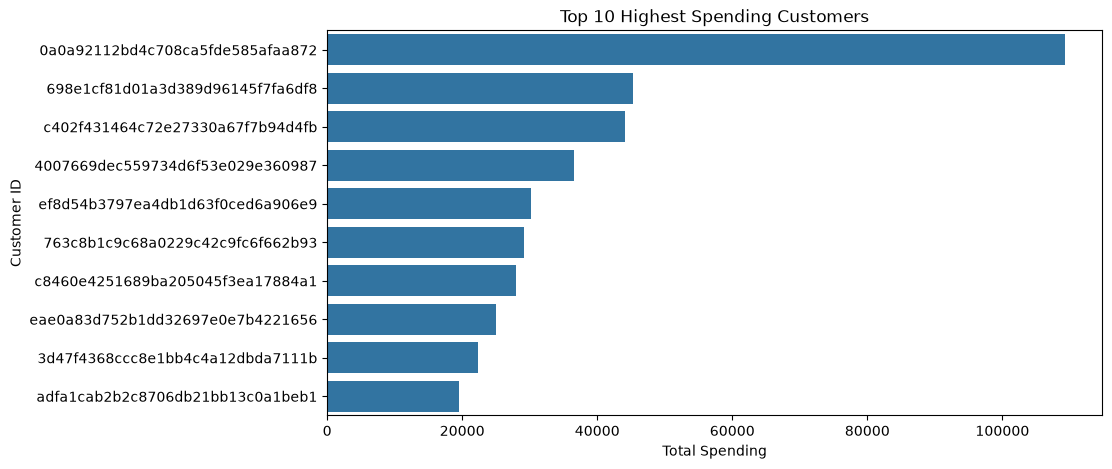

In [24]:
# Getting Customer spending data
customer_spending = (
    main_df.groupby('customer_unique_id')['total_payment_value']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
sns.barplot(
    x=customer_spending.values,
    y=customer_spending.index
)

plt.title("Top 10 Highest Spending Customers")
plt.xlabel("Total Spending")
plt.ylabel("Customer ID")
plt.show()
# Since we don't have custoemr name we use customer_unique_id

## Product Analysis

### Best-Selling Products

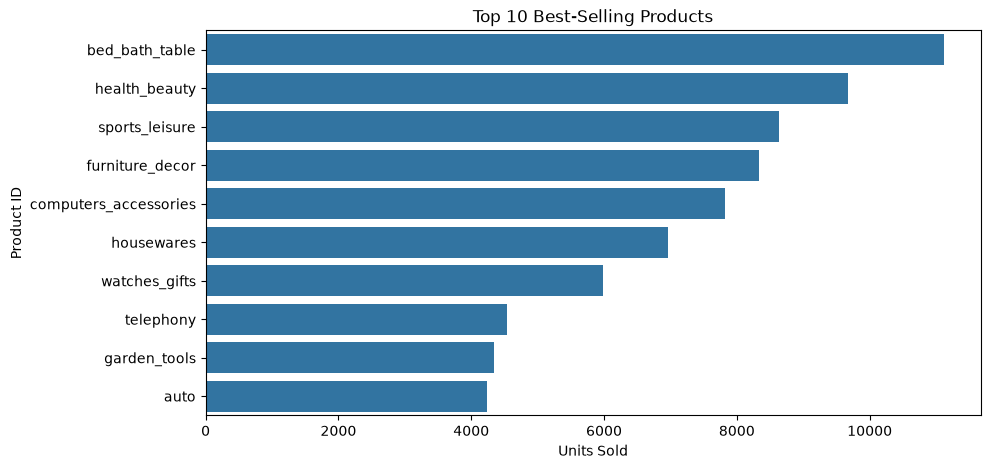

In [ ]:
# Getting top_products
top_products = (
    main_df.groupby('product_category_name_english')['order_item_id']
    .count()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
sns.barplot(x=top_products.values, y=top_products.index)

plt.title("Top 10 Best-Selling Products")
plt.xlabel("Products Sold")
plt.ylabel("Product Name")
plt.show()

### Product Pricing

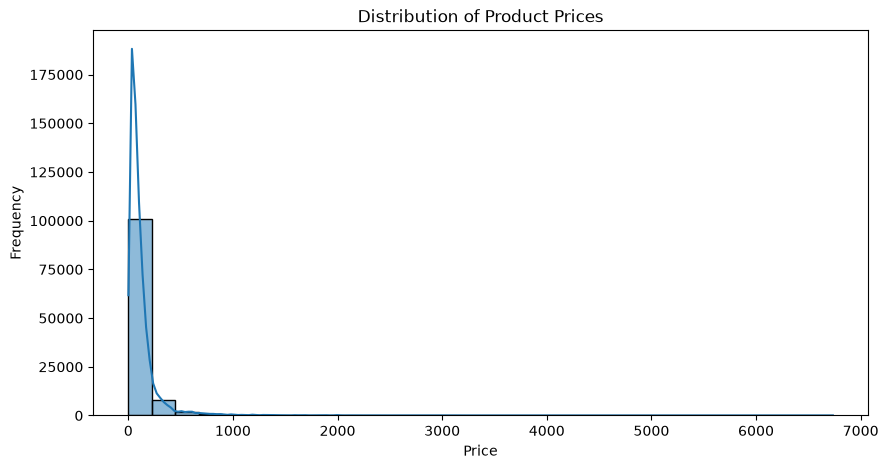

In [27]:
plt.figure(figsize=(10,5))
sns.histplot(main_df['price'], bins=30, kde=True)

plt.title("Distribution of Product Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

### Products Popularity

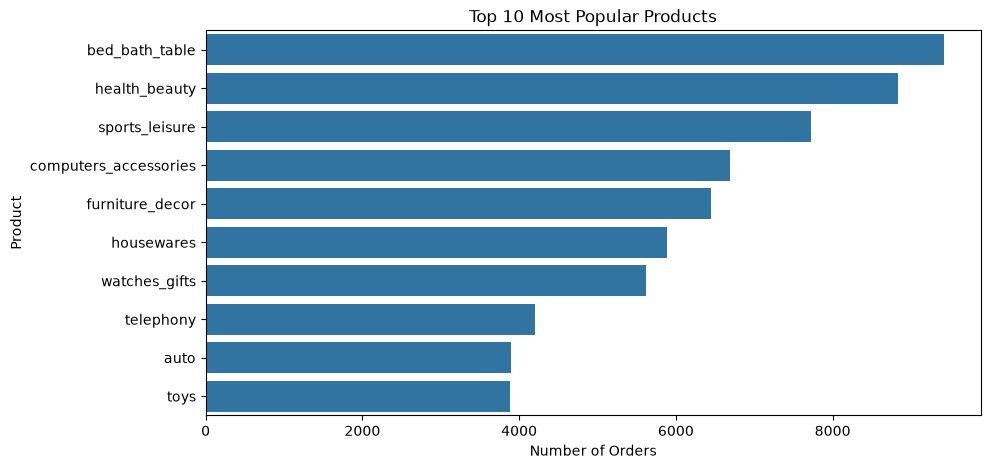

In [32]:
# Getting Top 10 products_popularity
product_popularity = (
    main_df.groupby('product_category_name_english')['order_id']
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
sns.barplot(x=product_popularity.values, y=product_popularity.index)

plt.title("Top 10 Most Popular Products")
plt.xlabel("Number of Orders")
plt.ylabel("Product")
plt.show()

## Seller Analysis

### Top_sellers

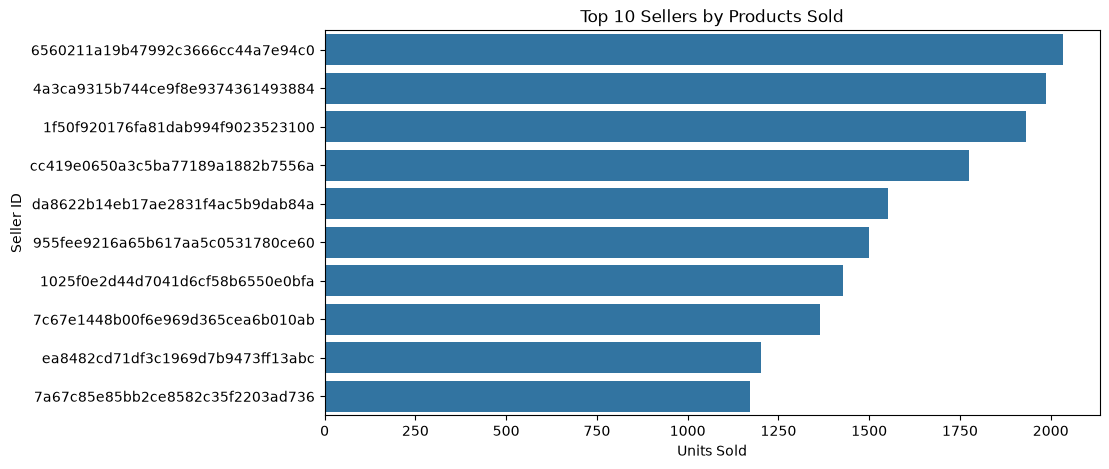

In [ ]:
top_sellers = (
    main_df.groupby('seller_id')
    .size()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
sns.barplot(x=top_sellers.values, y=top_sellers.index)

plt.title("Top 10 Sellers by Products Sold")
plt.xlabel("Units Sold")
plt.ylabel("Seller ID")
plt.show()
#Since we don't have seller name, use the sellers_id

### Reveneue by sellers

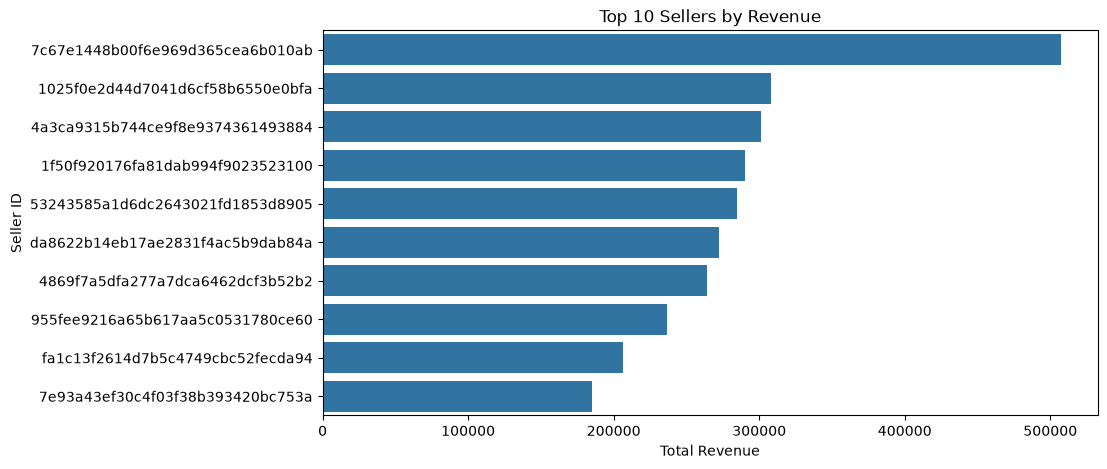

In [35]:
seller_revenue = (
    main_df.groupby('seller_id')['total_payment_value']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
sns.barplot(x=seller_revenue.values, y=seller_revenue.index)

plt.title("Top 10 Sellers by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Seller ID")
plt.show()

### Sellers Location

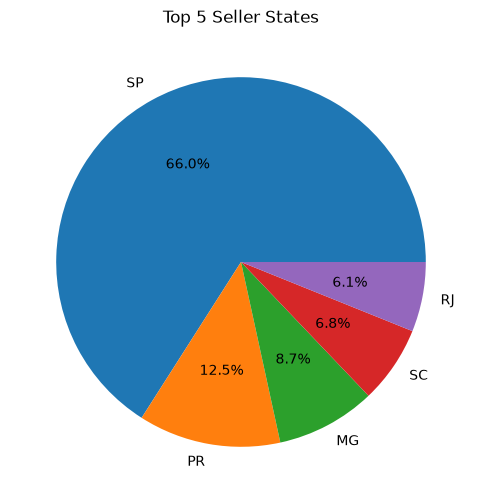

In [ ]:
seller_locations = (
    main_df.groupby('seller_state')['seller_id']
    .nunique()
    .sort_values(ascending=False)
    .head(5)
)

plt.figure(figsize=(6,6))
plt.pie(
    seller_locations,
    labels=seller_locations.index,
    autopct='%1.1f%%',
)

plt.title("Top 5 Seller States")
plt.show()

### Delivery Time Days

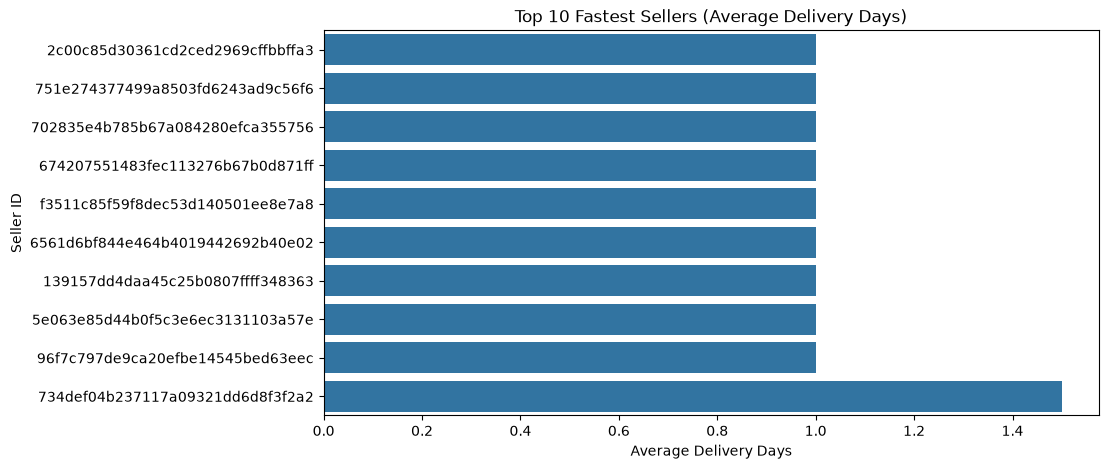

In [41]:
seller_delivery = (
    main_df.groupby('seller_id')['delivery_time_days']
    .mean() # Taking avg of all delivery_time_days by each seller_id group
    .sort_values()
    .head(10)
)

plt.figure(figsize=(10,5))
sns.barplot(x=seller_delivery.values, y=seller_delivery.index)

plt.title("Top 10 Fastest Sellers (Average Delivery Days)")
plt.xlabel("Average Delivery Days")
plt.ylabel("Seller ID")
plt.show()


## Delivery Analysis

### Delivery Delays

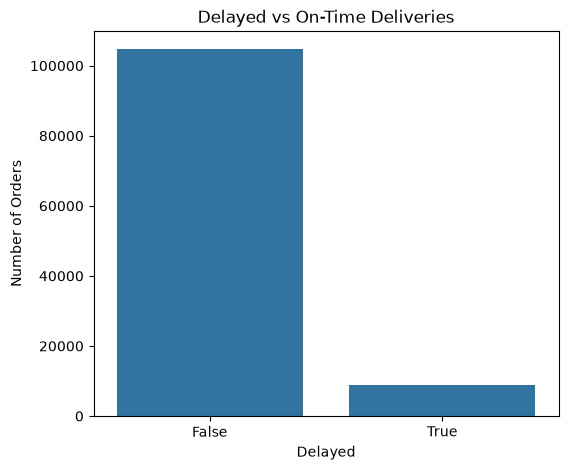

In [47]:
main_df['delivery_delays'] = (main_df['order_delivered_customer_date'] 
                              > main_df['order_estimated_delivery_date'])

plt.figure(figsize=(6,5))
sns.countplot(data=main_df, x='delivery_delays')

plt.title("Delayed vs On-Time Deliveries")
plt.xlabel("Delayed")
plt.ylabel("Number of Orders")
plt.show()

### Monthly Delivery Trends

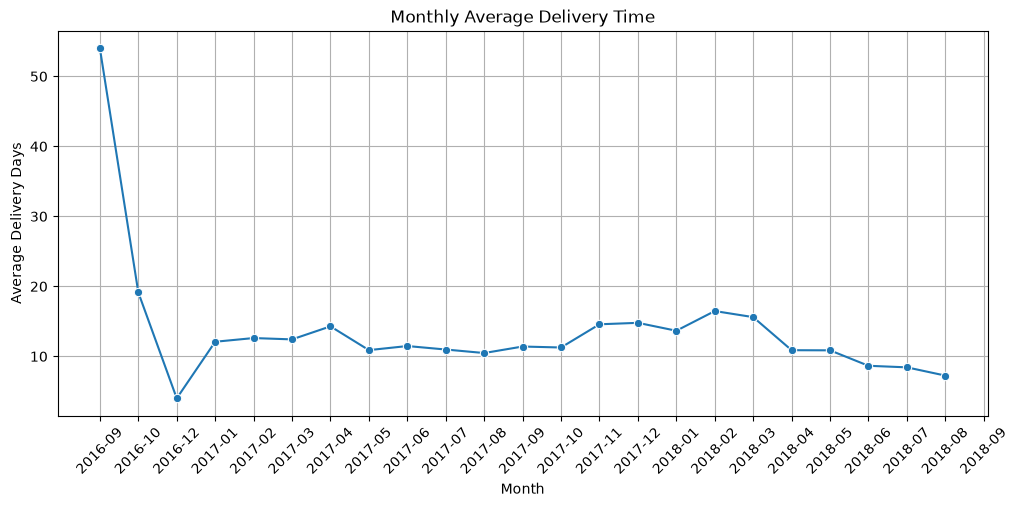

In [63]:
delivery_trends = (
    main_df.groupby(
        main_df['order_purchase_timestamp'].dt.to_period('M')
    )['delivery_time_days']
    .mean()
)

# Seaborn may not handle index it time data type
delivery_trends.index = delivery_trends.index.astype(str)

plt.figure(figsize=(12,5))
sns.lineplot(
    x=delivery_trends.index,
    y=delivery_trends.values,
    marker='o'
)

plt.xticks(rotation=45)

plt.title("Monthly Average Delivery Time")
plt.xlabel("Month")
plt.ylabel("Average Delivery Days")
plt.grid(True)
plt.show()

## Payment Analysis